In [37]:
%pip install numpy matplotlib meshio pygmsh pyvista anywidget 

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: c:\work\HP4\deepxde\.venv\Scripts\python.exe -m pip install --upgrade pip


In [38]:
import pygmsh
import numpy as np
import matplotlib.pyplot as plt
import json

# 設定
OUTPUT_FILE = 'input.json'

print("✅ Libraries loaded.")

✅ Libraries loaded.


In [39]:
# def generate_system_prompt():
#     # pygmsh.occ の正確なシグネチャを定義
#     reference_rules = """
# ### pygmsh.occ Code Generation Rules:
# 1. Geometry object: Use `geom` (already defined).
# 2. Rectangle: `rect = geom.add_rectangle([x0, y0, z0], width, height)`
# 3. Disk (Circle): `disk = geom.add_disk([xc, yc, zc], radius)`
# 4. Boolean Difference (A minus B): `geom.boolean_difference(A, B)`
# 5. Boolean Union (A plus B): `geom.boolean_union([list_of_entities])`
# 6. Precision: Always use float values (e.g., 100.0, not 100).
# 7. Output: Return ONLY pure Python code. No markdown code blocks, no explanations.
#     """

#     system_instruction = f"""
# You are an expert CAE Engineer specialized in pygmsh. 
# Create geometry definition code based on the user's vague request.
# {reference_rules}

# Example Request: "A square plate with a hole in the middle"
# Example Output:
# plate = geom.add_rectangle([0.0, 0.0, 0.0], 100.0, 100.0)
# hole = geom.add_disk([50.0, 50.0, 0.0], 20.0)
# geom.boolean_difference(plate, hole)
#     """
#     return system_instruction

# # これをLLMの「System Prompt」または「初期の指示文」として投げます
# print(generate_system_prompt())

In [40]:
rules_content = """# pygmsh.occ Geometry Generation Rules (Strict)

You are a CAD/CAE expert. Output ONLY valid Python code using the `pygmsh.occ` API.
The variable `geom` is already initialized.

### 1. Mandatory API Signatures:
- Rectangle: `rect = geom.add_rectangle([x0, y0, z0], width, height)`
- Disk (Circle): `disk = geom.add_disk([xc, yc, zc], radius)`
- Cylinder: `cyl = geom.add_cylinder([x0, y0, z0], [dx, dy, dz], radius)`
- Fillet (Edge rounding): `geom.add_fillet([line_entities], radius)`
- Boolean Union: `geom.boolean_union([entity1, entity2, ...])`
- Boolean Difference: `geom.boolean_difference(target_entity, tool_entity)`
- Boolean Intersection: `geom.boolean_intersection([entities])`

### 2. Physical Constraints:
- Use float values for all dimensions (e.g., 50.0).
- Ensure holes are completely contained within the base plate unless otherwise specified.
- Avoid perfectly overlapping edges from different operations to prevent mesh errors.

### 3. Output Format:
- No explanations, no markdown blocks (```), and no 'import' statements.
- Start directly with the geometry definitions.
- Assign the final resulting shape to a variable (e.g., `final_shape = ...`).

### 4. Physical Groups & Boundary Tags:
- To define boundaries for UNV/GMSH, use:
  `geom.add_physical(entity, label="MY_LABEL")`
- Example: `left_side = geom.add_rectangle(...)`, `geom.add_physical(left_side, "FIXED_SUPPORT")`
- This allows the UNV file to carry boundary condition information.

### 5. Essential for Export:
- When creating the final shape, always use `geom.add_physical(final_entity, "SURFACE")`.
- If the user specifies a boundary (e.g., "left edge"), create a curve and use `geom.add_physical(curve, "BC_NAME")`.
"""

# ファイルとして保存
with open("pygmsh_rules.txt", "w", encoding="utf-8") as f:
    f.write(rules_content)

print("✅ 'pygmsh_rules.txt' has been created successfully.")

✅ 'pygmsh_rules.txt' has been created successfully.


In [41]:
def generate_mesh_from_llm(recipe_code, mesh_size=10.0):
    """
    LLMが生成した形状レシピ（Pythonコード文字列）を実行し、
    pygmshを使用してメッシュを生成する関数。
    """
    try:
        with pygmsh.occ.Geometry() as geom:
            # メッシュサイズのグローバル設定
            geom.characteristic_length_min = mesh_size
            geom.characteristic_length_max = mesh_size
            
            # LLMが生成したコードを実行
            # 第2引数に、exec内で使用可能にする変数を辞書で渡します
            exec_globals = {"geom": geom}
            exec(recipe_code, exec_globals)
            
            # メッシュ生成
            mesh = geom.generate_mesh()
            return mesh
            
    except Exception as e:
        print(f"❌ Error during mesh generation: {e}")
        return None

User Prompt: 添付した pygmsh_rules.txt のルールを厳守して、以下の形状を作成するPythonコードを出力してください。

要望： 縦300、横800の板の左端を固定したい。中央に三角形のような配置で3つの小さな穴（半径10）を開け、さらに右端の上下の角に小さな切り欠きを作って。

In [54]:
# LLMから出力されたコードをここに貼り付ける
# (実際にはAPI連携などで自動化も可能)
# 改行を正しく入れ、要望（800x300, 3つの穴, 2つの切り欠き）を反映させました
LLM_GEOMETRY_RECIPE = """
# メインの板 (横700.0, 縦350.0)
plate = geom.add_rectangle([0.0, 0.0, 0.0], 700.0, 350.0)

# 2つの円孔 (半径12.0)
# 中央 (350, 175) より上下にオフセット
hole_upper = geom.add_disk([350.0, 225.0, 0.0], 12.0)
hole_lower = geom.add_disk([350.0, 125.0, 0.0], 12.0)

# 右端中央の切り欠き (幅50.0, 高さ30.0)
# 位置: x=650 (700-50), y=160 (175 - 30/2)
notch = geom.add_rectangle([650.0, 160.0, 0.0], 50.0, 30.0)

# ブーリアン演算で穴と切り欠きを差し引く
tools = geom.boolean_union([hole_upper, hole_lower, notch])
final_shape = geom.boolean_difference(plate, tools)

# 物理グループの設定
geom.add_physical(final_shape, "SURFACE")

# 左端の固定境界 (境界条件用)
# 左端の辺を抽出するための細い領域を定義
fixed_support = geom.add_rectangle([0.0, 0.0, 0.0], 0.1, 350.0)
geom.add_physical(fixed_support, "FIXED_LEFT")
"""

# def safe_mesh_execution(recipe, mesh_size=5.0):
#     import pygmsh
#     try:
#         with pygmsh.occ.Geometry() as geom:
#             geom.characteristic_length_min = mesh_size
#             geom.characteristic_length_max = mesh_size
            
#             # システムプロンプトで指示した通り、geom変数が存在する前提で実行
#             exec(recipe, {"geom": geom}) 
            
#             mesh = geom.generate_mesh()
#             return mesh
#     except Exception as e:
#         print(f"❌ LLMの生成コードにエラーがありました: {e}")
#         return None

# mesh = safe_mesh_execution(LLM_GEOMETRY_RECIPE)

def generate_mesh_from_llm(recipe_code, mesh_size=5.0):
    import pygmsh
    try:
        # 文字列から前後の空白やマークダウンのゴミを取り除く
        clean_code = recipe_code.strip().replace("```python", "").replace("```", "")
        
        with pygmsh.occ.Geometry() as geom:
            geom.characteristic_length_min = mesh_size
            geom.characteristic_length_max = mesh_size
            
            # 実行環境にgeomを渡す
            local_vars = {"geom": geom}
            exec(clean_code, {}, local_vars)
            
            mesh = geom.generate_mesh()
            return mesh
    except Exception as e:
        print(f"❌ Mesh generation failed: {e}")
        return None

In [55]:
# --- この1行を追加 ---
mesh = generate_mesh_from_llm(LLM_GEOMETRY_RECIPE, mesh_size=10.0)

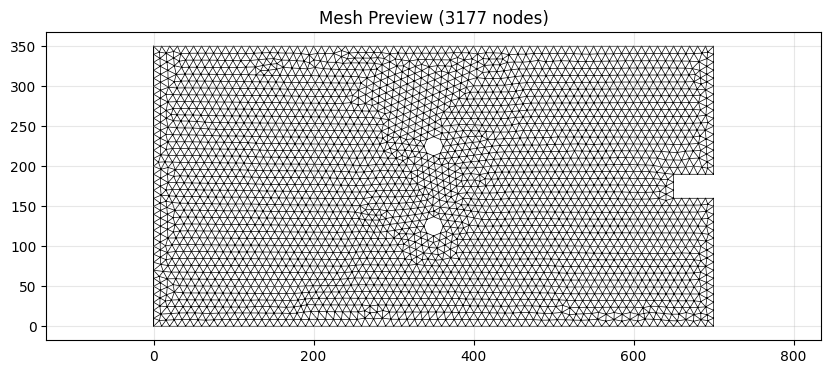

In [56]:
if mesh is not None:
    points = mesh.points
    triangles = mesh.cells_dict["triangle"]

    plt.figure(figsize=(10, 4))
    plt.triplot(points[:, 0], points[:, 1], triangles, lw=0.5, color='k')
    plt.title(f"Mesh Preview ({len(points)} nodes)")
    plt.axis('equal')
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("⚠️ No mesh to preview.")

In [57]:
# --- 5. 保存（形状データのみ） ---
if mesh is not None:
    nodes = mesh.points[:, :2]
    elements = mesh.cells_dict["triangle"]

    # 物理条件はここでは決めず、枠だけ作っておく
    input_data = {
        "nodes": nodes.tolist(),
        "elements": elements.tolist(),
        "material": {
            "E": 210000.0, 
            "thickness": 10.0
        },
        "conditions": {
            # 🌟 ここでは空にしておく（Pre側で判定させる）
            "fixed_nodes_x": [],
            "load_nodes": [],
            "total_force": 1000.0
        }
    }

    with open(OUTPUT_FILE, 'w') as f:
        json.dump(input_data, f, indent=4)
        
    print(f"🎉 Saved '{OUTPUT_FILE}' (Geometry only)")
    print(f"   Nodes: {len(nodes)}, Elements: {len(elements)}")
    print("   👉 Open the 'Pre' notebook to set boundary conditions.")

else:
    print("⚠️ Save skipped.")

🎉 Saved 'input.json' (Geometry only)
   Nodes: 3177, Elements: 6046
   👉 Open the 'Pre' notebook to set boundary conditions.


In [58]:
%pip install --upgrade meshio

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: c:\work\HP4\deepxde\.venv\Scripts\python.exe -m pip install --upgrade pip


In [59]:
# --- 6. メッシュのエクスポート (修正版) ---
GMSH_OUTPUT_FILE = 'model_mesh.msh'

if mesh is not None:
    try:
        import meshio
        
        # 2D解析に必要な 'triangle' 要素のみを抽出して新しいメッシュオブジェクトを作成
        # これにより、不要な点要素や線要素による dim_tags エラーを回避します
        cells = [("triangle", mesh.cells_dict["triangle"])]
        
        out_mesh = meshio.Mesh(
            points=mesh.points,
            cells=cells,
            # 必要に応じて cell_data も引き継げますが、まずは最小構成で
        )
        
        # GMSH 2.2 形式は互換性が非常に高く、多くのソフトで UNV 同様に扱えます
        out_mesh.write(GMSH_OUTPUT_FILE, file_format="gmsh22")
        
        print(f"🎉 Exported triangle mesh to '{GMSH_OUTPUT_FILE}' (GMSH 2.2 format)")
        
    except Exception as e:
        print(f"❌ Export failed: {e}")
else:
    print("⚠️ Export skipped.")

Warning: Appending zeros to replace the missing physical tag data.

Warning: Appending zeros to replace the missing geometrical tag data.

🎉 Exported triangle mesh to 'model_mesh.msh' (GMSH 2.2 format)
